# Lab 1 — Q-Learning

**Name:** Arnav Narula

**Roll No:** 2547115




In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

RNG_SEED = 42
np.random.seed(RNG_SEED)

EPISODE_CONFIGS = [500, 1_000, 2_000, 5_000, 10_000]
ALPHA = 0.1        # learning rate
GAMMA = 0.99       # discount factor
EPS_MAX = 1.0      # start fully exploratory
EPS_MIN = 0.01     # floor so the agent never stops exploring entirely
TEST_EPISODES = 100


In [ ]:
def train(num_episodes, alpha=ALPHA, gamma=GAMMA, eps_max=EPS_MAX, eps_min=EPS_MIN, seed=RNG_SEED):
    """Tabular Q-learning with epsilon-greedy exploration and exponential epsilon decay."""
    env = gym.make("FrozenLake-v1", is_slippery=True)
    n_states, n_actions = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_states, n_actions))

    decay_rate = 5.0 / num_episodes  # reaches ~eps_min by the end regardless of run length
    rewards_per_episode = np.zeros(num_episodes)

    for ep in range(num_episodes):
        epsilon = eps_min + (eps_max - eps_min) * np.exp(-decay_rate * ep)
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            target = reward + gamma * np.max(Q[next_state]) * (not terminated)
            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total_reward += reward

        rewards_per_episode[ep] = total_reward

    env.close()
    return Q, rewards_per_episode


def test_policy(Q, num_episodes=TEST_EPISODES, seed=RNG_SEED + 1000):
    """Run the greedy (exploration-free) policy and report the success rate."""
    env = gym.make("FrozenLake-v1", is_slippery=True)
    rewards = np.zeros(num_episodes)

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        while not done:
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards[ep] = total_reward

    env.close()
    success_rate = float(np.mean(rewards > 0))
    return success_rate, rewards


In [ ]:
def moving_average(x, window=100):
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    for i in range(len(x)):
        lo = max(0, i - window + 1)
        out[i] = x[lo:i + 1].mean()
    return out


results = {}
for n in EPISODE_CONFIGS:
    Q, rewards = train(n)
    cumulative = np.cumsum(rewards)
    avg_last_100 = moving_average(rewards, window=100)
    success_rate, test_rewards = test_policy(Q)

    results[n] = dict(
        Q=Q, rewards=rewards, cumulative=cumulative,
        avg_last_100=avg_last_100, success_rate=success_rate, test_rewards=test_rewards,
    )
    print(f"episodes={n:>6} | final train success (last 100 avg)={avg_last_100[-1]:.2f} "
          f"| test success rate={success_rate:.2%}")


episodes=   500 | final train success (last 100 avg)=0.09 | test success rate=6.00%
episodes=  1000 | final train success (last 100 avg)=0.20 | test success rate=17.00%
episodes=  2000 | final train success (last 100 avg)=0.69 | test success rate=68.00%
episodes=  5000 | final train success (last 100 avg)=0.68 | test success rate=70.00%
episodes= 10000 | final train success (last 100 avg)=0.63 | test success rate=70.00%


## Cumulative reward vs. training episodes

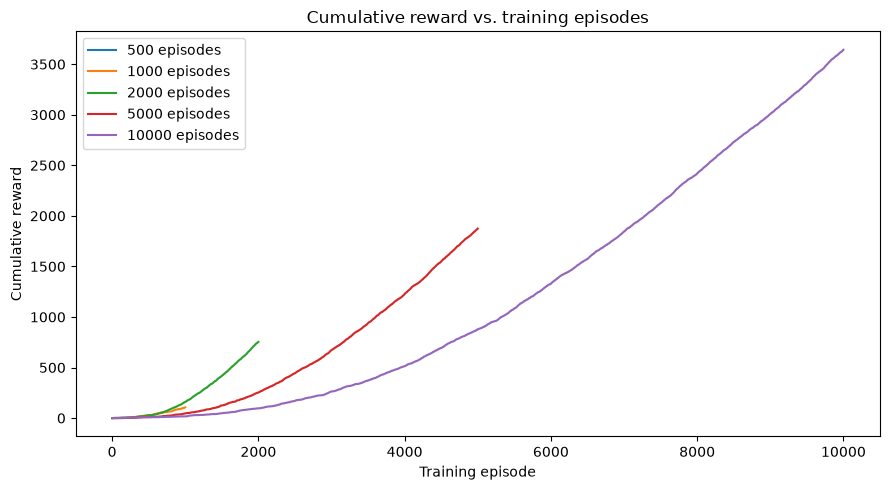

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for n in EPISODE_CONFIGS:
    ax.plot(np.arange(1, n + 1), results[n]["cumulative"], label=f"{n} episodes")
ax.set_xlabel("Training episode")
ax.set_ylabel("Cumulative reward")
ax.set_title("Cumulative reward vs. training episodes")
ax.legend()
plt.tight_layout()
plt.show()


## Average reward over the most recent 100 episodes

Cumulative reward always trends upward as episodes accumulate, which hides whether the
policy is actually improving. The rolling 100-episode average shows the real learning
curve instead.

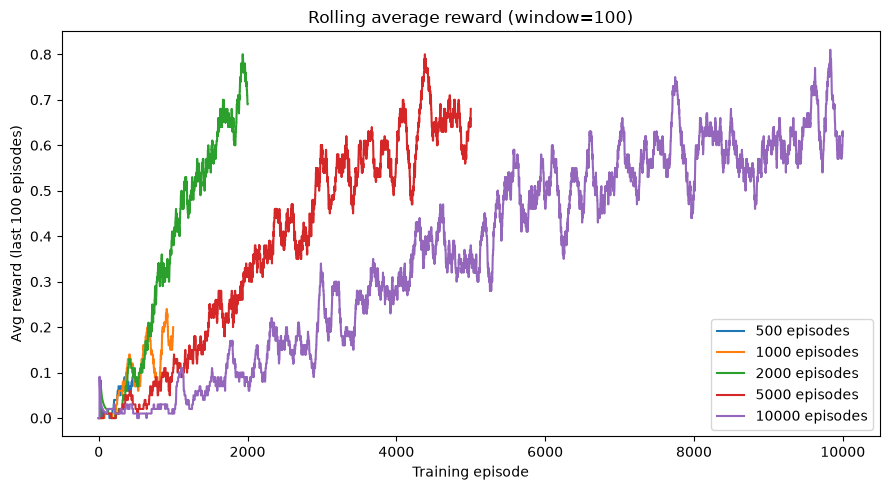

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for n in EPISODE_CONFIGS:
    ax.plot(np.arange(1, n + 1), results[n]["avg_last_100"], label=f"{n} episodes")
ax.set_xlabel("Training episode")
ax.set_ylabel("Avg reward (last 100 episodes)")
ax.set_title("Rolling average reward (window=100)")
ax.legend()
plt.tight_layout()
plt.show()


## Success rate after training (100 greedy test episodes)

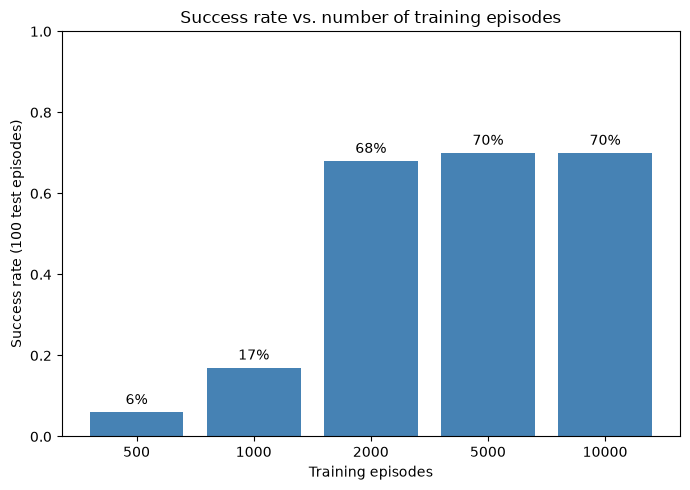

  Episodes | Success rate
       500 |        6.0%
      1000 |       17.0%
      2000 |       68.0%
      5000 |       70.0%
     10000 |       70.0%


In [ ]:
success_rates = [results[n]["success_rate"] for n in EPISODE_CONFIGS]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([str(n) for n in EPISODE_CONFIGS], success_rates, color="steelblue")
ax.set_xlabel("Training episodes")
ax.set_ylabel("Success rate (100 test episodes)")
ax.set_title("Success rate vs. number of training episodes")
ax.set_ylim(0, 1)
for b, r in zip(bars, success_rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.02, f"{r:.0%}", ha="center")
plt.tight_layout()
plt.show()

print(f"{'Episodes':>10} | {'Success rate':>12}")
for n, sr in zip(EPISODE_CONFIGS, success_rates):
    print(f"{n:>10} | {sr:>11.1%}")


## Environment visualisation

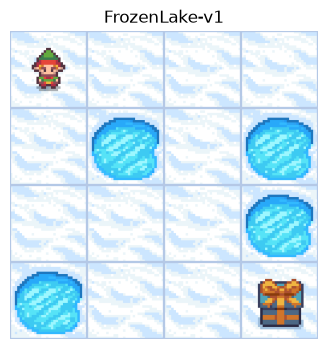

In [ ]:
render_env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
render_env.reset(seed=RNG_SEED)
frame = render_env.render()
render_env.close()

plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1")
plt.show()


## Extracted policy (best-trained agent, 10,000 episodes)

Arrows show the greedy action `argmax(Q[state])` learned for each state. `H` = hole,
`G` = goal — the agent doesn't need a policy there since those states end the episode.

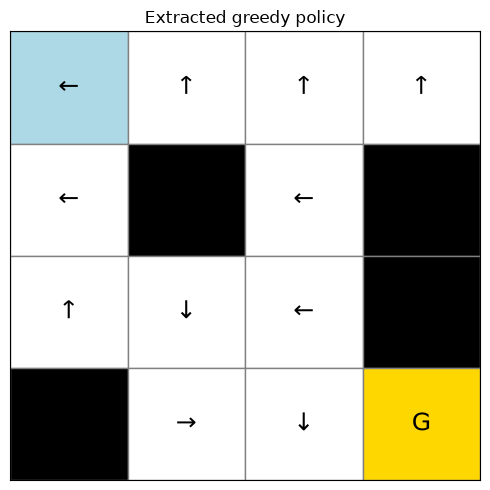

In [ ]:
FROZEN_LAKE_MAP = ["SFFF", "FHFH", "FFFH", "HFFG"]
ARROWS = {0: "\u2190", 1: "\u2193", 2: "\u2192", 3: "\u2191"}  # left, down, right, up

best_Q = results[EPISODE_CONFIGS[-1]]["Q"]
grid_size = len(FROZEN_LAKE_MAP)

fig, ax = plt.subplots(figsize=(5, 5))
for r, row in enumerate(FROZEN_LAKE_MAP):
    for c, tile in enumerate(row):
        state = r * grid_size + c
        if tile == "H":
            face, label = "black", "H"
        elif tile == "G":
            face, label = "gold", "G"
        else:
            label = ARROWS[int(np.argmax(best_Q[state]))]
            face = "lightblue" if tile == "S" else "white"
        ax.add_patch(plt.Rectangle((c, grid_size - 1 - r), 1, 1, facecolor=face, edgecolor="gray"))
        ax.text(c + 0.5, grid_size - 1 - r + 0.5, label, ha="center", va="center", fontsize=18)

ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Extracted greedy policy")
plt.tight_layout()
plt.show()
